# Salary ML — Model Estimasi Gaji (JobPath)

**Tujuan:** melatih model regresi untuk mengestimasi gaji lowongan yang kosong (**FR-8.01**).

**Pola pemakaian (write-time, bukan runtime):** hasil notebook ini adalah **artefak model** + fungsi **`predict_salary()`** yang dipakai saat menulis data ke database:
- di `data_ingestion.ipynb` (batch awal), dan
- saat fitur *Add Data Job* menambah lowongan baru tanpa gaji.

Nilai hasil prediksi disimpan sebagai kolom biasa (`salary_min`/`salary_max`) dengan penanda `is_salary_estimated = TRUE`, sehingga bisa difilter cepat oleh SQL dan tetap terbedakan dari gaji asli.

**Dasar data:** temuan `data_exploration.ipynb` — setelah dedup, 177 lowongan memiliki gaji numerik per bulan (data latih), sisanya kosong (target prediksi).

## Bagian 1 — Muat data & dedup

Konsisten dengan eksplorasi: baca `.jsonl`, buang 8 baris duplikat (identik pada judul+deskripsi+perusahaan+lokasi).

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

DATA_PATH = Path("..") / "dataset" / "jobs.jsonl"
records = []
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
df = df.drop_duplicates(
    subset=["job_title", "job_description", "company_name", "location"]
).reset_index(drop=True)
print(f"Jumlah baris setelah dedup: {len(df)}")

Jumlah baris setelah dedup: 465


## Bagian 2 — Bentuk target (`salary_mid`)

Gaji yang terisi berupa **range** atau **tunggal**. Target regresi memakai **titik tengah** (`salary_mid`) dari min/max, dalam satuan **juta Rupiah** agar mudah diinterpretasi. Hanya baris dengan gaji numerik per bulan yang dipakai sebagai data latih.

`parse_salary` sama dengan versi eksplorasi (membuang pemisah ribuan titik **maupun** koma).

In [2]:
def parse_salary(s):
    """Ekstrak (salary_min, salary_max, period) dari string salary mentah."""
    t = str(s).strip()
    if t.lower() in {"none", "null", "nan", "", "-"}:
        return pd.Series({"salary_min": np.nan, "salary_max": np.nan, "period": None})
    low = t.lower()
    if "month" in low or "bulan" in low:
        period = "month"
    elif "year" in low or "annum" in low or "tahun" in low:
        period = "year"
    elif "hour" in low or "jam" in low:
        period = "hour"
    else:
        period = None
    cleaned = t.replace("\xa0", " ").replace(".", "").replace(",", "")
    nums = [int(n) for n in re.findall(r"\d+", cleaned) if len(n) >= 4]
    if len(nums) >= 2:
        return pd.Series({"salary_min": min(nums[:2]), "salary_max": max(nums[:2]), "period": period})
    if len(nums) == 1:
        return pd.Series({"salary_min": nums[0], "salary_max": nums[0], "period": period})
    return pd.Series({"salary_min": np.nan, "salary_max": np.nan, "period": period})


sal = df["salary"].apply(parse_salary)
df = pd.concat([df, sal], axis=1)
df["salary_mid_juta"] = df[["salary_min", "salary_max"]].mean(axis=1) / 1_000_000

train_mask = df["salary_mid_juta"].notna() & (df["period"] == "month")
print(f"Baris data latih (gaji numerik per bulan): {train_mask.sum()}")
print(df.loc[train_mask, "salary_mid_juta"].describe().round(2))

Baris data latih (gaji numerik per bulan): 177
count    177.00
mean       9.03
std        4.95
min        3.50
25%        6.00
50%        7.50
75%       10.25
max       31.50
Name: salary_mid_juta, dtype: float64


## Bagian 3 — Feature engineering

Fitur diturunkan dari sinyal yang ditemukan di eksplorasi. **Fungsi-fungsi ini adalah inti yang dipakai ulang di ingestion** agar fitur konsisten antara saat latih dan saat prediksi.

| Fitur | Tipe | Sumber |
|---|---|---|
| `years_exp` | numerik | tahun pengalaman dari `job_description` |
| `seniority` | kategorik | kata kunci senioritas dari `job_title` |
| `role` | kategorik | kelompok peran dari `job_title` |
| `province` | kategorik | provinsi dari `location` (dikelompokkan) |
| `work_type` | kategorik | apa adanya |
| `arrangement` | kategorik | Onsite/Hybrid/Remote dari `location` |
| `desc_wordcount` | numerik | jumlah kata `job_description` |

In [3]:
SENIORITY_KEYWORDS = ["intern", "junior", "senior", "lead", "principal", "manager", "supervisor", "head", "staff"]
PROV_KEEP = {"Jakarta Raya", "Banten", "Jawa Barat", "Jawa Timur", "Bali"}


def extract_years(text):
    m = re.search(r"(\d+)\s*\+?\s*(?:years?|tahun|thn)", str(text), re.I)
    return float(m.group(1)) if m else np.nan


def seniority_from_title(title):
    t = str(title).lower()
    for kw in SENIORITY_KEYWORDS:
        if kw in t:
            return kw
    return "unspecified"


def role_family(title):
    t = str(title).lower()
    if any(k in t for k in ["data", "analyst", "scientist", "machine learning"]):
        return "Data/Analytics"
    if any(k in t for k in ["engineer", "developer", "programmer", "software", "devops", "qa"]):
        return "Engineering/IT"
    if any(k in t for k in ["sales", "marketing", "business development"]):
        return "Sales/Marketing"
    if any(k in t for k in ["hr", "human resource", "recruit", "talent", "people"]):
        return "HR"
    if any(k in t for k in ["design", "creative", "content", "graphic", "ui", "ux"]):
        return "Design/Creative"
    if any(k in t for k in ["finance", "accounting", "accountant", "tax", "audit"]):
        return "Finance"
    if any(k in t for k in ["manager", "supervisor", "head", "director"]):
        return "Management"
    return "Other"


def parse_location(loc):
    s = str(loc)
    low = s.lower()
    if "hibrid" in low or "hybrid" in low:
        arrangement = "Hybrid"
    elif "remote" in low or "jarak jauh" in low:
        arrangement = "Remote"
    else:
        arrangement = "Onsite"
    s2 = re.sub(r"\(.*?\)", "", s).replace("\n", " ").strip()
    parts = [p.strip() for p in s2.split(",") if p.strip()]
    province = parts[-1] if parts else "Unknown"
    return province, arrangement


def build_features(frame):
    """Bangun matriks fitur dari kolom mentah. Dipakai saat latih & saat prediksi."""
    out = []
    for _, r in frame.iterrows():
        province, arrangement = parse_location(r["location"])
        province = province if province in PROV_KEEP else "Other"
        out.append({
            "years_exp": extract_years(r["job_description"]),
            "seniority": seniority_from_title(r["job_title"]),
            "role": role_family(r["job_title"]),
            "province": province,
            "work_type": r["work_type"],
            "arrangement": arrangement,
            "desc_wordcount": len(str(r["job_description"]).split()),
        })
    return pd.DataFrame(out, index=frame.index)


X_all = build_features(df)
y_all = df["salary_mid_juta"]
X_all.head()

,years_exp,seniority,role,province,work_type,arrangement,desc_wordcount
0,2.0,unspecified,Data/Analytics,Banten,Full time,Onsite,123
1,NaN,intern,Data/Analytics,Jakarta Raya,Paruh waktu,Onsite,147
2,1.0,supervisor,Data/Analytics,Jawa Timur,Full time,Onsite,139
3,NaN,unspecified,Data/Analytics,Jakarta Raya,Full time,Onsite,230
4,NaN,unspecified,Data/Analytics,Jawa Barat,Full time,Onsite,55


In [4]:
# Data latih = baris dengan gaji numerik per bulan
X = X_all[train_mask].reset_index(drop=True)
y = y_all[train_mask].reset_index(drop=True)
print(f"X: {X.shape}, y: {y.shape}")
print("\nGaji rata-rata (juta) per role:")
print(X.assign(salary=y).groupby("role")["salary"].agg(["mean", "count"]).round(1).sort_values("mean", ascending=False))

X: (177, 7), y: (177,)

Gaji rata-rata (juta) per role:
                 mean  count
role                        
Management       14.0     16
Finance          12.8      2
Engineering/IT   12.2     10
Data/Analytics   11.4     21
Other             8.3     18
Sales/Marketing   8.0     58
HR                7.5     25
Design/Creative   6.7     27


## Bagian 4 — Perbandingan model (cross-validation)

Data latih kecil (177 baris), jadi model dijaga sederhana untuk menghindari overfit. Preprocessing: imputasi median + standardisasi untuk numerik, one-hot untuk kategorik. Target dilog-transform (`log1p`) karena gaji cenderung *right-skewed*.

Tiga kandidat dibandingkan dengan 5-fold CV: **Ridge**, **RandomForest**, **GradientBoosting**. Metrik: **MAE** (juta Rupiah, makin kecil makin baik) dan **R²**.

In [5]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate

NUM = ["years_exp", "desc_wordcount"]
CAT = ["seniority", "role", "province", "work_type", "arrangement"]

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])


def make_model(estimator):
    pipe = Pipeline([("pre", pre), ("est", estimator)])
    return TransformedTargetRegressor(pipe, func=np.log1p, inverse_func=np.expm1)


candidates = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=6, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
}

cv = KFold(n_splits=5, shuffle=True, random_state=0)
for name, est in candidates.items():
    res = cross_validate(make_model(est), X, y, cv=cv,
                         scoring=["neg_mean_absolute_error", "r2"])
    print(f"{name:18s} MAE={-res['test_neg_mean_absolute_error'].mean():.2f} juta  R2={res['test_r2'].mean():.2f}")

Ridge              MAE=2.41 juta  R2=0.39


RandomForest       MAE=2.74 juta  R2=0.27
GradientBoosting   MAE=2.80 juta  R2=0.25


## Bagian 5 — Evaluasi model terpilih

Model dengan MAE terbaik dipilih. Evaluasi memakai prediksi cross-validation (`cross_val_predict`) agar setiap baris diprediksi oleh model yang tidak melihatnya saat latih — plot prediksi vs aktual + MAE keseluruhan. Ditampilkan juga **permutation importance** untuk melihat fitur paling berpengaruh.

Model terpilih: Ridge (MAE CV = 2.41 juta)
MAE  : 2.41 juta
R2   : 0.39


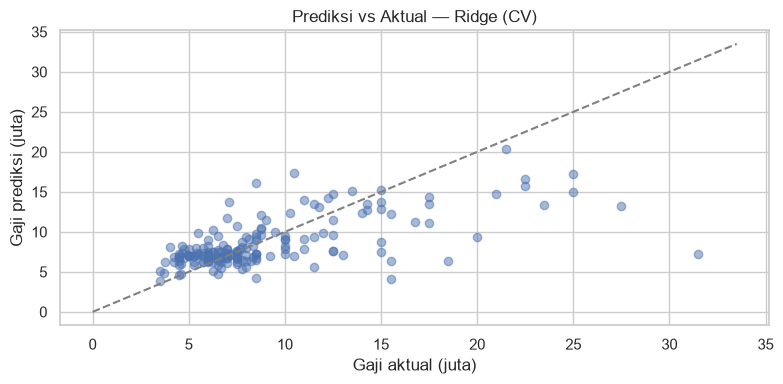

In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Pilih model dengan MAE CV terbaik
scores = {name: -cross_validate(make_model(est), X, y, cv=cv,
                                scoring="neg_mean_absolute_error")["test_score"].mean()
          for name, est in candidates.items()}
best_name = min(scores, key=scores.get)
print(f"Model terpilih: {best_name} (MAE CV = {scores[best_name]:.2f} juta)")

best_model = make_model(candidates[best_name])
y_pred_cv = cross_val_predict(best_model, X, y, cv=cv)
print(f"MAE  : {mean_absolute_error(y, y_pred_cv):.2f} juta")
print(f"R2   : {r2_score(y, y_pred_cv):.2f}")

fig, ax = plt.subplots()
ax.scatter(y, y_pred_cv, alpha=0.5, color="#4C72B0")
lim = [0, max(y.max(), y_pred_cv.max()) + 2]
ax.plot(lim, lim, "--", color="grey")
ax.set_xlabel("Gaji aktual (juta)"); ax.set_ylabel("Gaji prediksi (juta)")
ax.set_title(f"Prediksi vs Aktual — {best_name} (CV)")
plt.tight_layout(); plt.show()

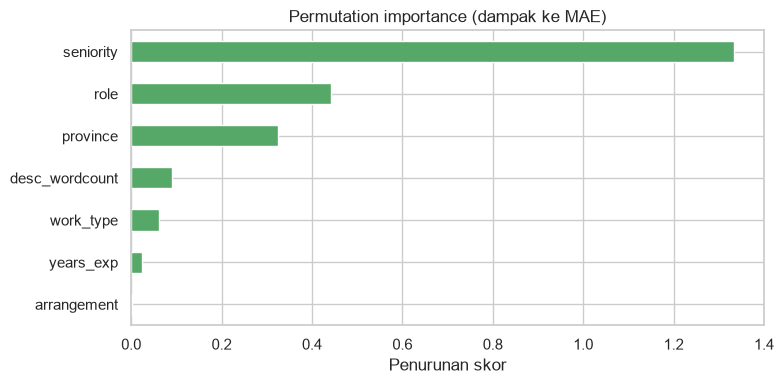

arrangement       0.003
years_exp         0.024
work_type         0.061
desc_wordcount    0.090
province          0.325
role              0.441
seniority         1.334
dtype: float64


In [7]:
# Permutation importance (dilatih pada seluruh data latih)
best_model.fit(X, y)
imp = permutation_importance(best_model, X, y, n_repeats=15, random_state=0,
                             scoring="neg_mean_absolute_error")
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()

ax = imp_s.plot(kind="barh", color="#55A868")
ax.set_title("Permutation importance (dampak ke MAE)"); ax.set_xlabel("Penurunan skor")
plt.tight_layout(); plt.show()
print(imp_s.round(3))

## Bagian 6 — Fungsi prediksi & simpan artefak

Model final dilatih pada seluruh data latih, lalu disimpan ke `../models/salary_model.joblib`. Fungsi `predict_salary()` menerima satu lowongan (dict/Series) dan mengembalikan estimasi gaji. **Fungsi inilah yang dipanggil di ingestion & Add Data Job** — memakai `build_features` yang sama.

In [8]:
import joblib

final_model = make_model(candidates[best_name])
final_model.fit(X, y)

MODEL_DIR = Path("..") / "models"
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(final_model, MODEL_DIR / "salary_model.joblib")
print(f"Artefak model disimpan: {(MODEL_DIR / 'salary_model.joblib').resolve()}")


def predict_salary(job):
    """Estimasi gaji untuk satu lowongan.

    job: dict/Series dengan minimal job_title, job_description, location, work_type.
    return: dict berisi estimasi dalam juta & Rupiah (per bulan).
    """
    feat = build_features(pd.DataFrame([dict(job)]))
    pred_juta = float(final_model.predict(feat)[0])
    return {
        "salary_estimate_juta": round(pred_juta, 2),
        "salary_estimate_rp": int(round(pred_juta * 1_000_000, -4)),
    }

Artefak model disimpan: C:\Users\yusuf\Documents\purwadhika_JCAIE\Finpro-JobApp\models\salary_model.joblib


In [9]:
# Demo: estimasi gaji untuk beberapa lowongan yang gajinya kosong
kosong = df[df["salary_mid_juta"].isna()]
for _, row in kosong.sample(6, random_state=0).iterrows():
    est = predict_salary(row)
    print(f"{row['job_title'][:45]:45s} @ {parse_location(row['location'])[0]:16s} -> "
          f"Rp {est['salary_estimate_rp']:,}/bln  (~{est['salary_estimate_juta']} juta)")

Sales Supervisor                              @ Jawa Timur       -> Rp 8,240,000/bln  (~8.24 juta)
Brand Manager (Hotto)                         @ Banten           -> Rp 13,900,000/bln  (~13.9 juta)
Senior Java Software Engineer - Indonesia - R @ Bali             -> Rp 20,090,000/bln  (~20.09 juta)
HRGA Supervisor                               @ Banten           -> Rp 10,410,000/bln  (~10.41 juta)
Staff Financial Analyst / Accounting          @ Jakarta Raya     -> Rp 9,920,000/bln  (~9.92 juta)
Data Engineer                                 @ Jakarta Raya     -> Rp 9,830,000/bln  (~9.83 juta)


## Bagian 7 — Kesimpulan

**Performa (5-fold CV).** Model terpilih **Ridge** — **MAE ≈ 2,41 juta**, **R² ≈ 0,39**. Dengan median gaji 7,5 juta, error ~2,4 juta berarti estimasi bersifat **kasar/indikatif**, bukan presisi. Model linier mengungguli RandomForest & GradientBoosting karena data latih kecil (177 baris) sehingga model kompleks cenderung *overfit*.

**Fitur paling berpengaruh** (permutation importance): `seniority` (jauh terbesar, ~1,33) > `role` (~0,44) > `province` (~0,33). Sesuai intuisi: senioritas, jenis peran, dan lokasi (premium Jakarta) adalah penentu utama gaji. `years_exp` kecil pengaruhnya (sering kosong dan tumpang tindih dengan `seniority`).

**Keterbatasan (dicatat jujur).**
- Data latih hanya 177 baris dengan fitur kasar → R² 0,39 wajar; jangan diperlakukan sebagai angka pasti.
- Target memakai titik tengah range; ketidakpastian range asli tidak dimodelkan.
- Semua data gaji per bulan; period lain (tahun/jam) belum ditangani.

**Pemakaian di hilir.** Artefak `models/salary_model.joblib` + fungsi `predict_salary()`. Di `data_ingestion.ipynb`, untuk lowongan tanpa gaji: isi `salary_min` = `salary_max` = hasil prediksi dan set **`is_salary_estimated = TRUE`**. UI dan Market Insight menandai nilai estimasi agar tidak tercampur dengan data asli.

**Peluang perbaikan (opsional).** Tambah data, ekstrak skill/tools dari `job_description` sebagai fitur tambahan, atau prediksi **interval** (min & max) alih-alih titik tunggal.